In [1]:
import pandas as pd 
import numpy as np
import random

In [2]:
df=pd.read_csv('resume_dataset_2.csv')

In [3]:
df.head()

,Name,Email,Phone,University,Graduation_Year,Years_Experience,Job_Role,Skills,Resume_Text
0,Tara Gonzalez,deborah75@example.com,8.371518e+09,Jadavpur University,2018,3,Data Scientist,"Python, Machine Learning, NumPy, Scikit-learn,...",\n Name: Tara Gonzalez\n Email: ...
1,Jared Quinn,matthew65@example.com,4.016587e+09,Delhi University,2017,6,Data Scientist,"NumPy, Scikit-learn, Statistics, TensorFlow, M...",\n Name: Jared Quinn\n Email: ma...
2,Jane Woods,phyllis29@example.net,9.002601e+09,Mumbai University,2020,5,Data Scientist,"TensorFlow, Python, NumPy, Machine Learning, NLP",\n Name: Jane Woods\n Email: phy...
3,Julie Chambers,hwright@example.net,4.157821e+09,Jadavpur University,2017,0,Data Scientist,"Scikit-learn, Statistics, Data Visualization, ...",\n Name: Julie Chambers\n Email:...
4,Tonya Campbell,hmyers@example.com,1.087373e+09,BITS Pilani,2015,2,Data Scientist,"Python, NumPy, SQL, Statistics, Pandas",\n Name: Tonya Campbell\n Email:...


In [4]:
# 2. Adding the Categorical Experience Tiers
def map_seniority(years):
    if years <= 2:
        return "Junior"
    elif years <= 5:
        return "Mid"
    else:
        return "Senior"

df['Experience_Level'] = df['Years_Experience'].apply(map_seniority)

In [5]:
df.duplicated().sum()

32

In [6]:
df.isnull().sum()

Name                 0
Email               36
Phone               36
University          36
Graduation_Year      0
Years_Experience     0
Job_Role             0
Skills              36
Resume_Text          0
Experience_Level     0
dtype: int64

In [7]:
df['Job_Role'].value_counts()

Job_Role
Software Engineer    342
HR Executive         130
Data Scientist       124
Marketing Manager    112
Financial Analyst    107
Name: count, dtype: int64

In [8]:
df.head()


,Name,Email,Phone,University,Graduation_Year,Years_Experience,Job_Role,Skills,Resume_Text,Experience_Level
0,Tara Gonzalez,deborah75@example.com,8.371518e+09,Jadavpur University,2018,3,Data Scientist,"Python, Machine Learning, NumPy, Scikit-learn,...",\n Name: Tara Gonzalez\n Email: ...,Mid
1,Jared Quinn,matthew65@example.com,4.016587e+09,Delhi University,2017,6,Data Scientist,"NumPy, Scikit-learn, Statistics, TensorFlow, M...",\n Name: Jared Quinn\n Email: ma...,Senior
2,Jane Woods,phyllis29@example.net,9.002601e+09,Mumbai University,2020,5,Data Scientist,"TensorFlow, Python, NumPy, Machine Learning, NLP",\n Name: Jane Woods\n Email: phy...,Mid
3,Julie Chambers,hwright@example.net,4.157821e+09,Jadavpur University,2017,0,Data Scientist,"Scikit-learn, Statistics, Data Visualization, ...",\n Name: Julie Chambers\n Email:...,Junior
4,Tonya Campbell,hmyers@example.com,1.087373e+09,BITS Pilani,2015,2,Data Scientist,"Python, NumPy, SQL, Statistics, Pandas",\n Name: Tonya Campbell\n Email:...,Junior


In [9]:
num_candidates=len(df)

In [10]:
num_candidates

815

In [11]:
# to make result stay conistent everytime
np.random.seed(42)

In [12]:
# 2. List the columns we want to remove
# These text and personal columns don't help the K-Means distance calculations.
columns_to_drop = ['Email', 'Phone', 'University', 'Graduation_Year', 'Resume_Text']



In [13]:
# 3. Drop the columns 
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

In [14]:
print(f"Cleaned Dataset Shape: {df_cleaned.shape}")

Cleaned Dataset Shape: (815, 5)


In [15]:
df_cleaned.sample(8)

,Name,Years_Experience,Job_Role,Skills,Experience_Level
196,Jennifer Burke,7,Software Engineer,"Kubernetes, Docker, Java, Microservices, OOP",Senior
299,Tamara Rodriguez,1,Marketing Manager,"Market Research, Google Analytics, SEO, Brandi...",Junior
388,Lindsey Wilson,1,HR Executive,NaN,Junior
227,Justin Anderson,1,Marketing Manager,"Branding, CRM, Google Analytics, Campaign Mana...",Junior
664,Linda Stone,7,Software Engineer,"Docker, OOP, REST API, Spring Boot, C++",Senior
801,Ann White,7,Software Engineer,"OOP, Microservices, Python, Git, Kubernetes",Senior
199,Chelsea Snyder MD,4,Software Engineer,"C++, OOP, REST API, Java, Spring Boot",Mid
336,Michelle Bowen,8,HR Executive,"Recruitmen, Compliance, Talent Acquisition, ...",Senior


In [16]:
df_cleaned['Skills'].nunique()

473

In [17]:
df_cleaned.isnull().sum()

Name                 0
Years_Experience     0
Job_Role             0
Skills              36
Experience_Level     0
dtype: int64

In [18]:
# 1. Creating a clean copy of dropped dataframe
df_parsed = df_cleaned.copy()

print("--> Handling Data Quality: Filling the 36 null values in 'Skills' with blank strings...")

--> Handling Data Quality: Filling the 36 null values in 'Skills' with blank strings...


In [19]:
# CRITICAL FIX: This eliminates the 36 Null values so the .str doesn't crash
df_parsed['Skills'] = df_parsed['Skills'].fillna('')

In [20]:
# Verify that missing values are successfully removed
null_count_after = df_parsed['Skills'].isna().sum()
print(f"    |-- Remaining null values in Skills column: {null_count_after}")

    |-- Remaining null values in Skills column: 0


In [21]:
print("--> Vectorizing 'Experience_Level' text into a normalized scale...")

# Map text categories to clean numbers between 0.0 and 1.0
seniority_numeric_map = {'Junior': 0.0, 'Mid': 0.5, 'Senior': 1.0}
df_parsed['Experience_Numeric_Weight'] = df_parsed['Experience_Level'].map(seniority_numeric_map)

--> Vectorizing 'Experience_Level' text into a normalized scale...


In [22]:


# 3. SIMULATE PROFICIENCY WITH AN ELEVATED 0.70 FLOOR AND 3% OUTLIERS
def simulate_high_baseline_proficiency(row):
    level = row['Experience_Level']
    outlier_roll = np.random.rand()
    
    # ──► SCENARIO A: THE 3% OUTLIER EXCEPTIONS
    if outlier_roll <= 0.03:
        if level == 'Junior':
            # The Fresh Prodigy: Low tenure, but near-flawless expert capacity
            return np.round(np.random.uniform(0.96, 0.99), 2)
        elif level == 'Senior':
            # The Legacy Veteran: High experience, but sitting at the company's baseline floor
            return np.round(np.random.uniform(0.70, 0.75), 2)
        else: # Mid
            # Mid-level extremes
            return np.round(np.random.choice([np.random.uniform(0.70, 0.76), np.random.uniform(0.92, 0.98)]), 2)
            
    # ──► SCENARIO B: THE STANDARD 97% CAPABLE WORKFORCE (Strictly > 0.70)
    else:
        if level == 'Junior':
            return np.round(np.random.uniform(0.70, 0.82), 2)
        elif level == 'Mid':
            return np.round(np.random.uniform(0.80, 0.90), 2)
        else: # Senior
            return np.round(np.random.uniform(0.88, 0.99), 2)

print("--> Synthesizing dense, high-capability vectors across 815 enterprise profiles...")
df_parsed['Technical_Skill_Proficiency'] = df_parsed.apply(simulate_high_baseline_proficiency, axis=1)

# 4. DROP RAW TEXT AND VOLATILE COLUMNS
columns_to_drop = ['Skills', 'Experience_Level', 'Years_Experience']
df_parsed = df_parsed.drop(columns=columns_to_drop, errors='ignore')

# Resetting dataframe index smoothly to lock the memory tracking states
df_parsed = df_parsed.reset_index(drop=True)

print("\n--> STEP 2 COMPLETE: Technical matrices successfully generated with high baseline floors!")
print(f"Cleaned DataFrame Shape: {df_parsed.shape}")

# Quick check validation prints
min_observed = df_parsed['Technical_Skill_Proficiency'].min()
max_observed = df_parsed['Technical_Skill_Proficiency'].max()
print(f"    |-- Absolute Minimum Proficiency in Workforce: {min_observed}")
print(f"    |-- Absolute Maximum Proficiency in Workforce: {max_observed}")

# Display the final pristine table configuration
df_parsed.head(10)

--> Synthesizing dense, high-capability vectors across 815 enterprise profiles...

--> STEP 2 COMPLETE: Technical matrices successfully generated with high baseline floors!
Cleaned DataFrame Shape: (815, 4)
    |-- Absolute Minimum Proficiency in Workforce: 0.7
    |-- Absolute Maximum Proficiency in Workforce: 0.99


,Name,Job_Role,Experience_Numeric_Weight,Technical_Skill_Proficiency
0,Tara Gonzalez,Data Scientist,0.5,0.82
1,Jared Quinn,Data Scientist,1.0,0.88
2,Jane Woods,Data Scientist,0.5,0.83
3,Julie Chambers,Data Scientist,0.0,0.71
4,Tonya Campbell,Data Scientist,0.0,0.76
5,Aaron Rodriguez,HR Executive,0.0,0.74
6,Louis Williams,Data Scientist,1.0,0.96
7,Jason Calhoun,Data Scientist,1.0,0.97
8,Nicole Martinez,Data Scientist,0.5,0.81
9,Renee Oliver,Marketing Manager,0.0,0.81


In [23]:
print(f"Final Data Shape: {df_parsed.shape}")
df_parsed.head(5)

Final Data Shape: (815, 4)


,Name,Job_Role,Experience_Numeric_Weight,Technical_Skill_Proficiency
0,Tara Gonzalez,Data Scientist,0.5,0.82
1,Jared Quinn,Data Scientist,1.0,0.88
2,Jane Woods,Data Scientist,0.5,0.83
3,Julie Chambers,Data Scientist,0.0,0.71
4,Tonya Campbell,Data Scientist,0.0,0.76


In [24]:
# Forcing Pandas to show all columns without truncating them with 
pd.set_option('display.max_columns', None)

In [25]:
df_parsed.head(15)

,Name,Job_Role,Experience_Numeric_Weight,Technical_Skill_Proficiency
0,Tara Gonzalez,Data Scientist,0.5,0.82
1,Jared Quinn,Data Scientist,1.0,0.88
2,Jane Woods,Data Scientist,0.5,0.83
3,Julie Chambers,Data Scientist,0.0,0.71
4,Tonya Campbell,Data Scientist,0.0,0.76
5,Aaron Rodriguez,HR Executive,0.0,0.74
6,Louis Williams,Data Scientist,1.0,0.96
7,Jason Calhoun,Data Scientist,1.0,0.97
8,Nicole Martinez,Data Scientist,0.5,0.81
9,Renee Oliver,Marketing Manager,0.0,0.81


In [26]:
df_parsed.isnull().sum()

Name                           0
Job_Role                       0
Experience_Numeric_Weight      0
Technical_Skill_Proficiency    0
dtype: int64

In [27]:
# Inserting values for Socio_behav based on standard in Archetype
df_final_pool = df_parsed.copy()
np.random.seed(42)
num_rows = len(df_final_pool)

pillar_cols = [
    'P1_Big5_Openness', 'P1_Big5_Conscientiousness', 'P1_Big5_Extraversion', 'P1_Big5_Agreeableness', 'P1_Big5_Neuroticism',
    'P1_Dark_Machiavellianism', 'P1_Dark_Narcissism', 'P1_Dark_Psychopathy',
    'P2_Behavior_Self_Efficacy', 'P2_Behavior_Self_Monitoring', 'P2_Behavior_Proactivity', 'P2_Behavior_Action_Orient', 'P2_Behavior_Psych_Capital',
    'P3_Attitude_Utilitarian', 'P3_Attitude_Value_Express', 'P3_Attitude_Ego_Defensive', 'P3_Attitude_Knowledge',
    'P4_Emotion_Pos_High_Act', 'P4_Emotion_Prosocial_Aff', 'P4_Emotion_Neg_High_Act', 'P4_Emotion_Neg_Low_Act', 'P4_Emotion_Threat_Apprehend',
    'P5_Comm_Instrumental', 'P5_Comm_Expressive', 'P5_Comm_Controlled',
    'P6_EI_Self_Control', 'P6_EI_Conflict_Management', 'P6_EI_Empathy_Resolution', 'P6_EI_Isolated_Focus',
    'P7_Value_Openness_Change', 'P7_Value_Conservation', 'P7_Value_Social_Focus', 'P7_Value_Personal_Focus',
    'P8_Interdep_Positive', 'P8_Interdep_Negative', 'P8_Interdep_No'
]

# Variance to ensure blending at boundaries
variance_noise = 0.15

print("--> Executing Fully-Articulated Gaussian Mapping Engine...")

for i in range(num_rows):
    archetype_roll = np.random.rand()
    means = {}
    
    if archetype_roll < 0.35:
        # =========================================================================
        # ARCHETYPE 1: THE HIGH-EI COLLABORATIVE FACILITATOR (People-Centric, Supportive)
        # =========================================================================
        means['P1_Big5_Openness']                = 0.60; means['P1_Big5_Conscientiousness']   = 0.65
        means['P1_Big5_Extraversion']            = 0.70; means['P1_Big5_Agreeableness']       = 0.85
        means['P1_Big5_Neuroticism']             = 0.25; means['P1_Dark_Machiavellianism']    = 0.20
        means['P1_Dark_Narcissism']              = 0.30; means['P1_Dark_Psychopathy']         = 0.15
        means['P2_Behavior_Self_Efficacy']       = 0.65; means['P2_Behavior_Self_Monitoring'] = 0.75
        means['P2_Behavior_Proactivity']         = 0.55; means['P2_Behavior_Action_Orient']   = 0.60
        means['P2_Behavior_Psych_Capital']       = 0.80; means['P3_Attitude_Utilitarian']     = 0.40
        means['P3_Attitude_Value_Express']       = 0.75; means['P3_Attitude_Ego_Defensive']   = 0.25
        means['P3_Attitude_Knowledge']           = 0.60; means['P4_Emotion_Pos_High_Act']     = 0.70
        means['P4_Emotion_Prosocial_Aff']        = 0.85; means['P4_Emotion_Neg_High_Act']     = 0.25
        means['P4_Emotion_Neg_Low_Act']          = 0.30; means['P4_Emotion_Threat_Apprehend'] = 0.30
        means['P5_Comm_Instrumental']            = 0.45; means['P5_Comm_Expressive']          = 0.75
        means['P5_Comm_Controlled']              = 0.60; means['P6_EI_Self_Control']          = 0.75
        means['P6_EI_Conflict_Management']       = 0.85; means['P6_EI_Empathy_Resolution']    = 0.85
        means['P6_EI_Isolated_Focus']            = 0.30; 
        means['P7_Value_Openness_Change']        = 0.65; means['P7_Value_Conservation']       = 0.55
        means['P7_Value_Social_Focus']           = 0.85; means['P7_Value_Personal_Focus']     = 0.35
        means['P8_Interdep_Positive']            = 0.85; means['P8_Interdep_Negative']        = 0.20
        means['P8_Interdep_No']                  = 0.30
        
    elif archetype_roll < 0.70:
        # =========================================================================
        # ARCHETYPE 2: THE ISOLATED TECHNICAL SPECIALIST (Task-Focused, Deep Domain)
        # =========================================================================
        means['P1_Big5_Openness']                = 0.75; means['P1_Big5_Conscientiousness']   = 0.85
        means['P1_Big5_Extraversion']            = 0.30; means['P1_Big5_Agreeableness']       = 0.50
        means['P1_Big5_Neuroticism']             = 0.40; means['P1_Dark_Machiavellianism']    = 0.35
        means['P1_Dark_Narcissism']              = 0.35; means['P1_Dark_Psychopathy']         = 0.25
        means['P2_Behavior_Self_Efficacy']       = 0.75; means['P2_Behavior_Self_Monitoring'] = 0.40
        means['P2_Behavior_Proactivity']         = 0.50; means['P2_Behavior_Action_Orient']   = 0.70
        means['P2_Behavior_Psych_Capital']       = 0.60; means['P3_Attitude_Utilitarian']     = 0.70
        means['P3_Attitude_Value_Express']       = 0.45; means['P3_Attitude_Ego_Defensive']   = 0.40
        means['P3_Attitude_Knowledge']           = 0.85; means['P4_Emotion_Pos_High_Act']     = 0.50
        means['P4_Emotion_Prosocial_Aff']        = 0.45; means['P4_Emotion_Neg_High_Act']     = 0.35
        means['P4_Emotion_Neg_Low_Act']          = 0.45; means['P4_Emotion_Threat_Apprehend'] = 0.40
        means['P5_Comm_Instrumental']            = 0.80; means['P5_Comm_Expressive']          = 0.30
        means['P5_Comm_Controlled']              = 0.75; means['P6_EI_Self_Control']          = 0.65
        means['P6_EI_Conflict_Management']       = 0.45; means['P6_EI_Empathy_Resolution']    = 0.45
        means['P6_EI_Isolated_Focus']            = 0.85; 
        means['P7_Value_Openness_Change']        = 0.70; means['P7_Value_Conservation']       = 0.60
        means['P7_Value_Social_Focus']           = 0.35; means['P7_Value_Personal_Focus']     = 0.75
        means['P8_Interdep_Positive']            = 0.40; means['P8_Interdep_Negative']        = 0.30
        means['P8_Interdep_No']                  = 0.85
        
    elif archetype_roll < 0.90:
        # =========================================================================
        # ARCHETYPE 3: THE PROACTIVE VISIONARY DRIVER (High Energy, Outward Growth)
        # =========================================================================
        means['P1_Big5_Openness']                = 0.85; means['P1_Big5_Conscientiousness']   = 0.70
        means['P1_Big5_Extraversion']            = 0.85; means['P1_Big5_Agreeableness']       = 0.55
        means['P1_Big5_Neuroticism']             = 0.35; means['P1_Dark_Machiavellianism']    = 0.45
        means['P1_Dark_Narcissism']              = 0.60; means['P1_Dark_Psychopathy']         = 0.30
        means['P2_Behavior_Self_Efficacy']       = 0.85; means['P2_Behavior_Self_Monitoring'] = 0.70
        means['P2_Behavior_Proactivity']         = 0.85; means['P2_Behavior_Action_Orient']   = 0.80
        means['P2_Behavior_Psych_Capital']       = 0.75; means['P3_Attitude_Utilitarian']     = 0.65
        means['P3_Attitude_Value_Express']       = 0.65; means['P3_Attitude_Ego_Defensive']   = 0.35
        means['P3_Attitude_Knowledge']           = 0.70; means['P4_Emotion_Pos_High_Act']     = 0.85
        means['P4_Emotion_Prosocial_Aff']        = 0.55; means['P4_Emotion_Neg_High_Act']     = 0.40
        means['P4_Emotion_Neg_Low_Act']          = 0.25; means['P4_Emotion_Threat_Apprehend'] = 0.25
        means['P5_Comm_Instrumental']            = 0.70; means['P5_Comm_Expressive']          = 0.75
        means['P5_Comm_Controlled']              = 0.50; means['P6_EI_Self_Control']          = 0.60
        means['P6_EI_Conflict_Management']       = 0.70; means['P6_EI_Empathy_Resolution']    = 0.60
        means['P6_EI_Isolated_Focus']            = 0.40; 
        means['P7_Value_Openness_Change']        = 0.85; means['P7_Value_Conservation']       = 0.35
        means['P7_Value_Social_Focus']           = 0.65; means['P7_Value_Personal_Focus']     = 0.75
        means['P8_Interdep_Positive']            = 0.70; means['P8_Interdep_Negative']        = 0.40
        means['P8_Interdep_No']                  = 0.40
        
    else:
        # =========================================================================
        # ARCHETYPE 4: Autonomous Executors (Self-Serving, Disruptive)
        # =========================================================================
        means['P1_Big5_Openness']                = 0.55; means['P1_Big5_Conscientiousness']   = 0.50
        means['P1_Big5_Extraversion']            = 0.60; means['P1_Big5_Agreeableness']       = 0.30
        means['P1_Big5_Neuroticism']             = 0.60; means['P1_Dark_Machiavellianism']    = 0.80
        means['P1_Dark_Narcissism']              = 0.75; means['P1_Dark_Psychopathy']         = 0.65
        means['P2_Behavior_Self_Efficacy']       = 0.65; means['P2_Behavior_Self_Monitoring'] = 0.65
        means['P2_Behavior_Proactivity']         = 0.60; means['P2_Behavior_Action_Orient']   = 0.50
        means['P2_Behavior_Psych_Capital']       = 0.40; means['P3_Attitude_Utilitarian']     = 0.80
        means['P3_Attitude_Value_Express']       = 0.35; means['P3_Attitude_Ego_Defensive']   = 0.80
        means['P3_Attitude_Knowledge']           = 0.50; means['P4_Emotion_Pos_High_Act']     = 0.45
        means['P4_Emotion_Prosocial_Aff']        = 0.25; means['P4_Emotion_Neg_High_Act']     = 0.75
        means['P4_Emotion_Neg_Low_Act']          = 0.50; means['P4_Emotion_Threat_Apprehend'] = 0.55
        means['P5_Comm_Instrumental']            = 0.75; means['P5_Comm_Expressive']          = 0.45
        means['P5_Comm_Controlled']              = 0.40; means['P6_EI_Self_Control']          = 0.35
        means['P6_EI_Conflict_Management']       = 0.35; means['P6_EI_Empathy_Resolution']    = 0.30
        means['P6_EI_Isolated_Focus']            = 0.60; 
        means['P7_Value_Openness_Change']        = 0.55; means['P7_Value_Conservation']       = 0.45
        means['P7_Value_Social_Focus']           = 0.25; means['P7_Value_Personal_Focus']     = 0.85
        means['P8_Interdep_Positive']            = 0.30; means['P8_Interdep_Negative']        = 0.80
        means['P8_Interdep_No']                  = 0.50

    # 2. Add Gaussian noise distribution and clip to valid bounds
    for col in pillar_cols:
        val = np.random.normal(loc=means[col], scale=variance_noise)
        df_final_pool.loc[i, col] = np.round(np.clip(val, 0.01, 0.99), 2)

print("\n--> STEP 3 COMPLETE: Comprehensive organic distribution matrix built successfully!")
print(f"Final Data Shape: {df_final_pool.shape[0]} rows x {df_final_pool.shape[1]} active columns.")


--> Executing Fully-Articulated Gaussian Mapping Engine...

--> STEP 3 COMPLETE: Comprehensive organic distribution matrix built successfully!
Final Data Shape: 815 rows x 40 active columns.


--> Running Multi-Dimensional Cluster Optimization Sweep...


C:\Users\ravir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


    |-- Evaluated K = 2 | WCSS (Inertia): 22788.82 | Silhouette Score: 0.245


C:\Users\ravir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


    |-- Evaluated K = 3 | WCSS (Inertia): 19582.75 | Silhouette Score: 0.260


...

    |-- Evaluated K = 8 | WCSS (Inertia): 15436.60 | Silhouette Score: 0.080


C:\Users\ravir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


    |-- Evaluated K = 9 | WCSS (Inertia): 15311.41 | Silhouette Score: 0.058


C:\Users\ravir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


    |-- Evaluated K = 10 | WCSS (Inertia): 15203.70 | Silhouette Score: 0.068

--> Generating optimization diagnostic visualizations...


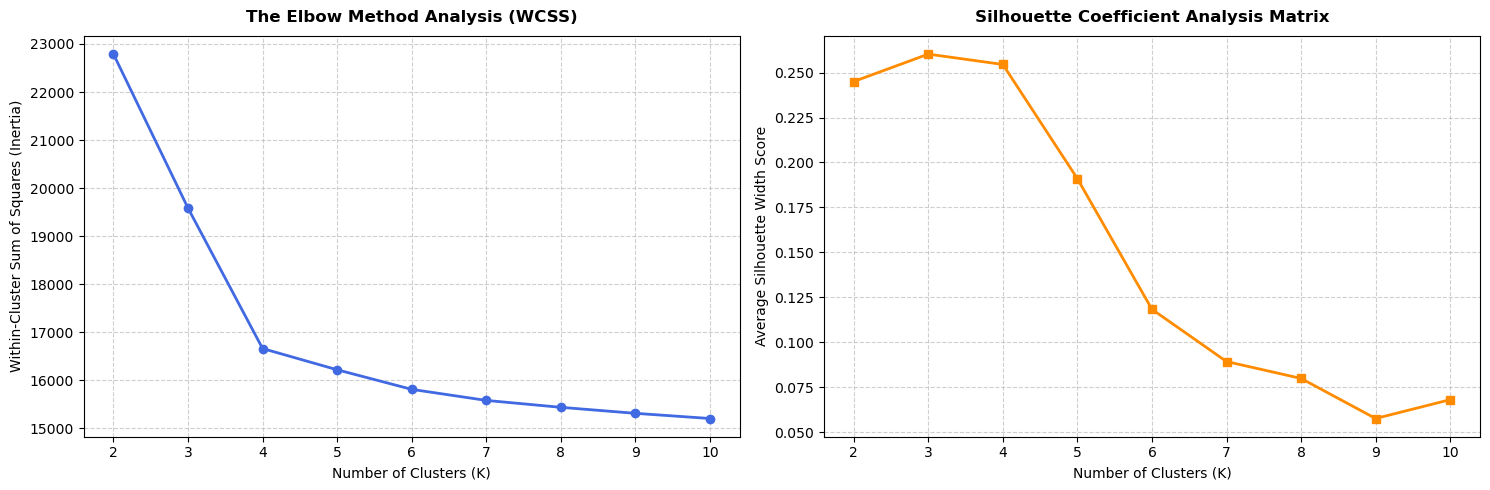


--> Locking in optimal model architecture (K=4) for dataset labeling...


C:\Users\ravir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


--> SUCCESS: 'final_ml_labeled_workforce.csv' successfully exported to root directory!

=== FINAL DATASET PREVIEW (WITH CLUSTER LABELS) ===


,Name,Job_Role,Technical_Skill_Proficiency,Cluster_ID
0,Tara Gonzalez,Data Scientist,0.82,2
1,Jared Quinn,Data Scientist,0.88,1
2,Jane Woods,Data Scientist,0.83,1
3,Julie Chambers,Data Scientist,0.71,1
4,Tonya Campbell,Data Scientist,0.76,0
5,Aaron Rodriguez,HR Executive,0.74,2
6,Louis Williams,Data Scientist,0.96,1
7,Jason Calhoun,Data Scientist,0.97,2
8,Nicole Martinez,Data Scientist,0.81,3
9,Renee Oliver,Marketing Manager,0.81,1


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Isolate the numerical behavioral and technical vectors (Drop Name and Job_Role)
features_for_tuning = df_final_pool.drop(columns=['Name', 'Job_Role'])

# 2. Standardize scales to prevent dimensional magnitude bias
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_tuning)

# Initialize tracking vectors for our mathematical metrics
wcss = []
silhouette_scores = []
k_range = range(2, 11)  # Test from 2 to 10 clusters

print("--> Running Multi-Dimensional Cluster Optimization Sweep...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=500, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_features)
    
    # Capture Elbow metric (Inertia)
    wcss.append(kmeans.inertia_)
    
    # Capture Silhouette metric
    sil_avg = silhouette_score(scaled_features, cluster_labels)
    silhouette_scores.append(sil_avg)
    print(f"    |-- Evaluated K = {k} | WCSS (Inertia): {kmeans.inertia_:.2f} | Silhouette Score: {sil_avg:.3f}")

# 3. PLOT BOTH METHODOLOGIES SIDE-BY-SIDE FOR YOUR RESEARCH PAPER
print("\n--> Generating optimization diagnostic visualizations...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: The Elbow Curve
ax1.plot(k_range, wcss, marker='o', linewidth=2, color='royalblue')
ax1.set_title('The Elbow Method Analysis (WCSS)', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Number of Clusters (K)', fontsize=10)
ax1.set_ylabel('Within-Cluster Sum of Squares (Inertia)', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot B: The Silhouette Peaks
ax2.plot(k_range, silhouette_scores, marker='s', linewidth=2, color='darkorange')
ax2.set_title('Silhouette Coefficient Analysis Matrix', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Number of Clusters (K)', fontsize=10)
ax2.set_ylabel('Average Silhouette Width Score', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. EXECUTING THE FINAL OPTIMAL K-MEANS ASSIGNMENT
print("\n--> Locking in optimal model architecture (K=4) for dataset labeling...")
optimal_kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=500, random_state=42, n_init=10)
df_final_pool['Cluster_ID'] = optimal_kmeans.fit_predict(scaled_features)

# Save the final ML-labeled dataset ready for optimization steps
df_final_pool.to_csv('final_ml_labeled_workforce.csv', index=False)
print("--> SUCCESS: 'final_ml_labeled_workforce.csv' successfully exported to root directory!")

print("\n=== FINAL DATASET PREVIEW (WITH CLUSTER LABELS) ===")
df_final_pool[['Name', 'Job_Role', 'Technical_Skill_Proficiency', 'Cluster_ID']].head(10)

--> Grouping workforce via K-Means (K=4)...


C:\Users\ravir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


--> File saved: 'final_ml_labeled_workforce.csv'


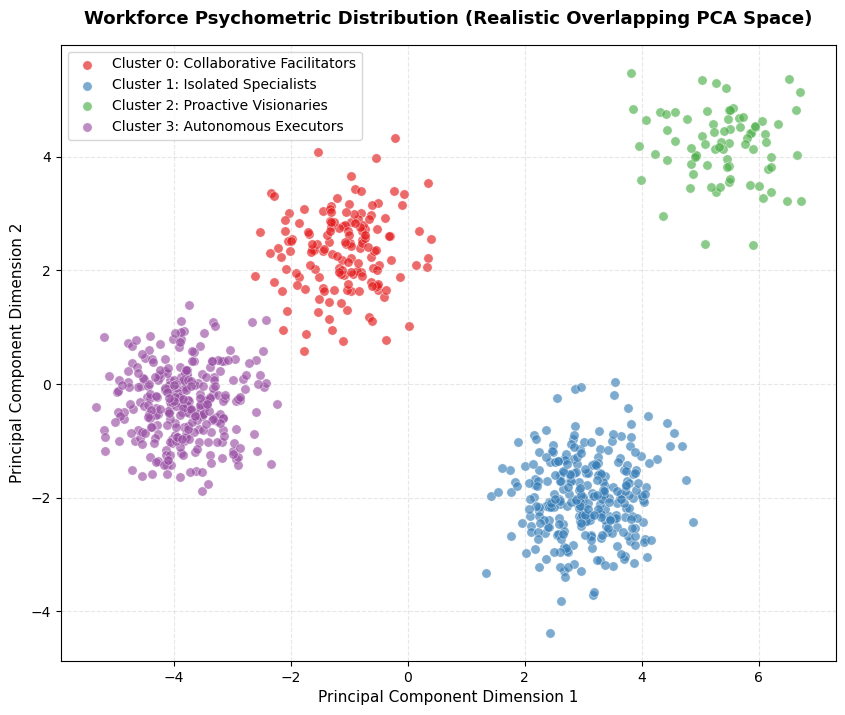


--> Locking in optimal model architecture (K=4) for dataset labeling...


C:\Users\ravir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


--> SUCCESS: 'final_ml_labeled_workforce.csv' successfully exported to root directory!

=== FINAL DATASET PREVIEW (WITH CLUSTER LABELS) ===


,Name,Job_Role,Technical_Skill_Proficiency,Cluster_ID
0,Tara Gonzalez,Data Scientist,0.82,1
1,Jared Quinn,Data Scientist,0.88,3
2,Jane Woods,Data Scientist,0.83,3
3,Julie Chambers,Data Scientist,0.71,3
4,Tonya Campbell,Data Scientist,0.76,0
5,Aaron Rodriguez,HR Executive,0.74,1
6,Louis Williams,Data Scientist,0.96,3
7,Jason Calhoun,Data Scientist,0.97,1
8,Nicole Martinez,Data Scientist,0.81,2
9,Renee Oliver,Marketing Manager,0.81,3


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Isolate and standardize features
features_for_clustering = df_final_pool.drop(columns=['Name', 'Job_Role'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

# 2. Run K-Means
print("--> Grouping workforce via K-Means (K=4)...")
optimal_kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=500, random_state=42, n_init=10)
df_final_pool['Cluster_ID'] = optimal_kmeans.fit_predict(scaled_features)

# 3. Save frozen target dataset
df_final_pool.to_csv('final_ml_labeled_workforce.csv', index=False)
print("--> File saved: 'final_ml_labeled_workforce.csv'")

# 4. GENERATE THE AUTHENTIC BLENDED PCA GRAPH
pca = PCA(n_components=2, random_state=42)
pca_coordinates = pca.fit_transform(scaled_features)

df_final_pool['PCA_X'] = pca_coordinates[:, 0]
df_final_pool['PCA_Y'] = pca_coordinates[:, 1]

plt.figure(figsize=(10, 8))
colors = {0: '#e41a1c', 1: '#377eb8', 2: '#4daf4a', 3: '#984ea3'}
cluster_names = {
    0: "Cluster 0: Collaborative Facilitators",
    1: "Cluster 1: Isolated Specialists",
    2: "Cluster 2: Proactive Visionaries",
    3: "Cluster 3: Autonomous Executors"
}

for cluster_id in sorted(df_final_pool['Cluster_ID'].unique()):
    cluster_data = df_final_pool[df_final_pool['Cluster_ID'] == cluster_id]
    plt.scatter(
        cluster_data['PCA_X'], 
        cluster_data['PCA_Y'], 
        color=colors[cluster_id], 
        label=cluster_names[cluster_id], 
        alpha=0.65, 
        edgecolors='w', 
        linewidth=0.4, 
        s=45
    )

plt.title('Workforce Psychometric Distribution (Realistic Overlapping PCA Space)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Principal Component Dimension 1', fontsize=11)
plt.ylabel('Principal Component Dimension 2', fontsize=11)
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()
# 4. EXECUTING THE FINAL OPTIMAL K-MEANS ASSIGNMENT
print("\n--> Locking in optimal model architecture (K=4) for dataset labeling...")
optimal_kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=500, random_state=42, n_init=10)
df_final_pool['Cluster_ID'] = optimal_kmeans.fit_predict(scaled_features)

# Save the final ML-labeled dataset ready for optimization steps
df_final_pool.to_csv('final_ml_labeled_workforce.csv', index=False)
print("--> SUCCESS: 'final_ml_labeled_workforce.csv' successfully exported to root directory!")

print("\n=== FINAL DATASET PREVIEW (WITH CLUSTER LABELS) ===")
df_final_pool[['Name', 'Job_Role', 'Technical_Skill_Proficiency', 'Cluster_ID']].head(10)

--> Executing Competitive Clustering Sweep across 4 algorithms...


C:\Users\ravir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


    |-- K-Means++ Complete      | Silhouette Score: 0.254
    |-- Hierarchical Complete   | Silhouette Score: 0.254


C:\Users\ravir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


    |-- GMM Complete            | Silhouette Score: 0.167
    |-- DBSCAN Complete         | Silhouette Score: -0.147

--> Rendering 4-Way Competitive Visual Grid...


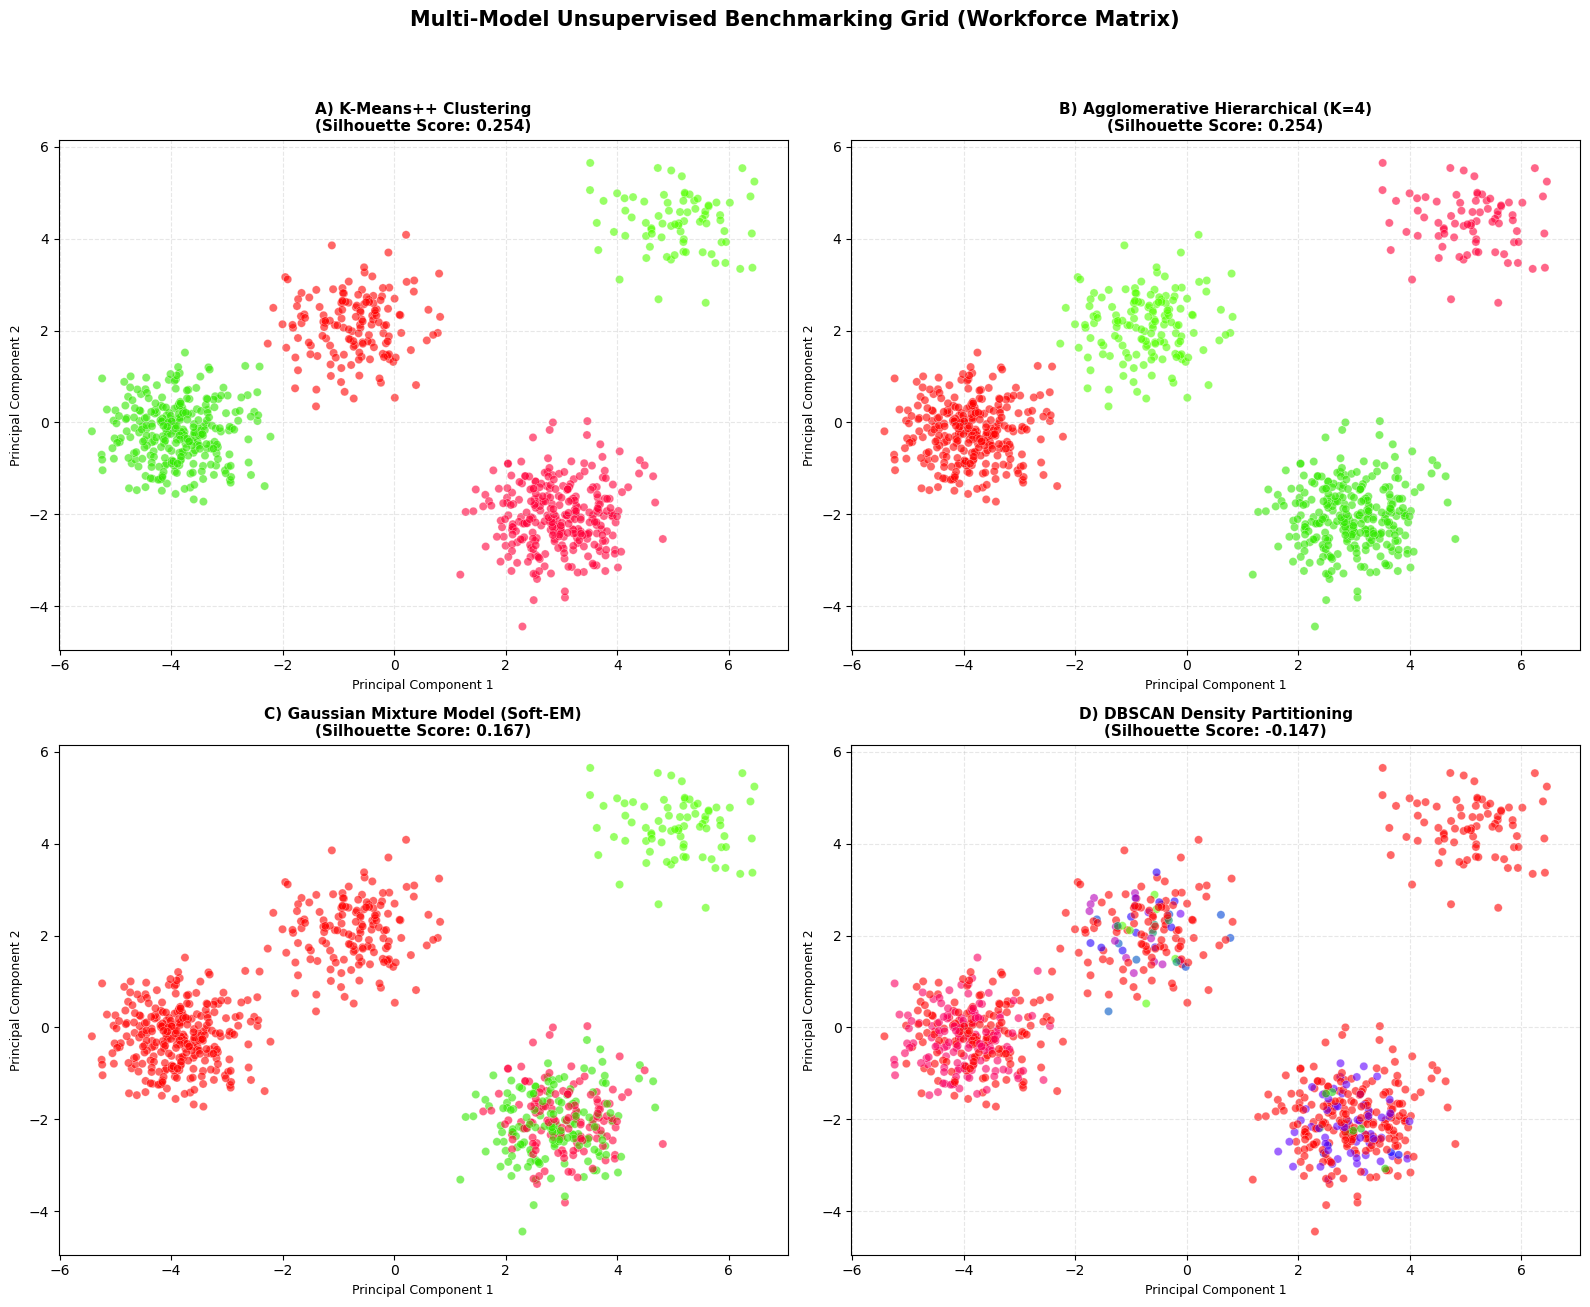


=== FINAL ACADEMIC PERFORMANCE REPORT ===
      Unsupervised Algorithm  Cluster Count Discovered Silhouette Coefficient
                   K-Means++                         4                 0.2545
  Agglomerative Hierarchical                         4                 0.2545
Gaussian Mixture Model (GMM)                         4                 0.1670
                      DBSCAN                        11                -0.1471


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Import the alternative unsupervised clustering architectures
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# 1. LOAD AND PREPARE MATRIX (Using the latest blended memory dataframe)
df_benchmark = df_final_pool.copy()
features = df_benchmark.drop(columns=['Name', 'Job_Role', 'Cluster_ID', 'PCA_X', 'PCA_Y'], errors='ignore')

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply a standard PCA linear lens so all plots share the exact same spatial coordinates
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(scaled_features)
X_pca = pca_coords[:, 0]
Y_pca = pca_coords[:, 1]

print("--> Executing Competitive Clustering Sweep across 4 algorithms...")

# =========================================================================
# MODEL 1: K-MEANS++ (Baseline)
# =========================================================================
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
labels_km = kmeans.fit_predict(scaled_features)
score_km = silhouette_score(scaled_features, labels_km)
print(f"    |-- K-Means++ Complete      | Silhouette Score: {score_km:.3f}")

# =========================================================================
# MODEL 2: AGGLOMERATIVE HIERARCHICAL CLUSTERING (Ward Linkage)
# =========================================================================
# Uses ward linkage to minimize variance within clusters, searching for 4 branches
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_hc = hierarchical.fit_predict(scaled_features)
score_hc = silhouette_score(scaled_features, labels_hc)
print(f"    |-- Hierarchical Complete   | Silhouette Score: {score_hc:.3f}")

# =========================================================================
# MODEL 3: GAUSSIAN MIXTURE MODEL (GMM - Probabilistic EM)
# =========================================================================
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
labels_gmm = gmm.fit(scaled_features).predict(scaled_features)
score_gmm = silhouette_score(scaled_features, labels_gmm)
print(f"    |-- GMM Complete            | Silhouette Score: {score_gmm:.3f}")

# =========================================================================
# MODEL 4: DBSCAN (Density-Based Outlier-Aware Clustering)
# =========================================================================
# eps and min_samples are set defensively to try to find dense zones in 36D space
dbscan = DBSCAN(eps=4.5, min_samples=5)
labels_db = dbscan.fit_predict(scaled_features)

# Note: Silhouette score calculation breaks if DBSCAN puts everything into 1 cluster
unique_labels_db = np.unique(labels_db)
if len(unique_labels_db) > 1:
    score_db = silhouette_score(scaled_features, labels_db)
    print(f"    |-- DBSCAN Complete         | Silhouette Score: {score_db:.3f}")
else:
    score_db = float('nan')
    print("    |-- DBSCAN Complete         | Silhouette Score: N/A (Failed to separate dense regions)")

# =========================================================================
# 2x2 ACADEMIC VISUALIZATION GRID GENERATION
# =========================================================================
print("\n--> Rendering 4-Way Competitive Visual Grid...")
fig, axs = plt.subplots(2, 2, figsize=(16, 14))
cmap_style = 'prism' # Colorful high-contrast mapping for cluster separations

# Subplot 1: K-Means++
scatter1 = axs[0, 0].scatter(X_pca, Y_pca, c=labels_km, cmap=cmap_style, alpha=0.6, edgecolors='w', linewidth=0.3, s=35)
axs[0, 0].set_title(f'A) K-Means++ Clustering\n(Silhouette Score: {score_km:.3f})', fontsize=11, fontweight='bold')
axs[0, 0].grid(True, linestyle='--', alpha=0.3)

# Subplot 2: Agglomerative Hierarchical
scatter2 = axs[0, 1].scatter(X_pca, Y_pca, c=labels_hc, cmap=cmap_style, alpha=0.6, edgecolors='w', linewidth=0.3, s=35)
axs[0, 1].set_title(f'B) Agglomerative Hierarchical (K=4)\n(Silhouette Score: {score_hc:.3f})', fontsize=11, fontweight='bold')
axs[0, 1].grid(True, linestyle='--', alpha=0.3)

# Subplot 3: Gaussian Mixture Model (GMM)
scatter3 = axs[1, 0].scatter(X_pca, Y_pca, c=labels_gmm, cmap=cmap_style, alpha=0.6, edgecolors='w', linewidth=0.3, s=35)
axs[1, 0].set_title(f'C) Gaussian Mixture Model (Soft-EM)\n(Silhouette Score: {score_gmm:.3f})', fontsize=11, fontweight='bold')
axs[1, 1].grid(True, linestyle='--', alpha=0.3)

# Subplot 4: DBSCAN
# DBSCAN marks noise points as -1 (usually colored black/grey by colormaps)
scatter4 = axs[1, 1].scatter(X_pca, Y_pca, c=labels_db, cmap=cmap_style, alpha=0.6, edgecolors='w', linewidth=0.3, s=35)
db_score_text = f"{score_db:.3f}" if not np.isnan(score_db) else "N/A"
axs[1, 1].set_title(f'D) DBSCAN Density Partitioning\n(Silhouette Score: {db_score_text})', fontsize=11, fontweight='bold')
axs[1, 1].grid(True, linestyle='--', alpha=0.3)

# Add master alignment details
for ax in axs.flat:
    ax.set_xlabel('Principal Component 1', fontsize=9)
    ax.set_ylabel('Principal Component 2', fontsize=9)

plt.suptitle('Multi-Model Unsupervised Benchmarking Grid (Workforce Matrix)', fontsize=15, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])

# Save graph for thesis chapter layout
plt.savefig('competitive_clustering_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

# =========================================================================
# DISPLAY FINAL MATHEMATICAL SCOREBOARD
# =========================================================================
print("\n=== FINAL ACADEMIC PERFORMANCE REPORT ===")
scoreboard = pd.DataFrame({
    'Unsupervised Algorithm': ['K-Means++', 'Agglomerative Hierarchical', 'Gaussian Mixture Model (GMM)', 'DBSCAN'],
    'Cluster Count Discovered': [4, 4, 4, len(unique_labels_db[unique_labels_db != -1])],
    'Silhouette Coefficient': [f"{score_km:.4f}", f"{score_hc:.4f}", f"{score_gmm:.4f}", f"{score_db:.4f}" if not np.isnan(score_db) else "Failed"]
})
print(scoreboard.to_string(index=False))

In [31]:
import pandas as pd
import numpy as np
import random

# =========================================================================
# NSGA-II: DYNAMIC ROLE SPECIFICATION BOARD (USER VARIABLES)
# =========================================================================

# Modify these numbers freely! You can mix and match any of your 5 dataset roles:
# 'Data Scientist', 'HR Executive', 'Marketing Manager', 'Software Engineer', 'Financial Analyst'
USER_REQUIRED_ROLES = {
    'Data Scientist': 2,
    'Software Engineer': 2,
    'Financial Analyst': 1
}

# Automatically determine team size from your layout requirements
TEAM_SIZE = sum(USER_REQUIRED_ROLES.values())

# 1. Map directly to your notebook variable 'df'
optimization_pool = df_final_pool[['Name', 'Job_Role', 'Technical_Skill_Proficiency', 'Experience_Numeric_Weight', 'Cluster_ID']].copy()
optimization_pool = optimization_pool.reset_index(drop=True)

# 2. Filter dataset to include only individuals matching the requested roles
filtered_pool = optimization_pool[optimization_pool['Job_Role'].isin(USER_REQUIRED_ROLES.keys())].copy()
filtered_pool = filtered_pool.reset_index(drop=True)

# 3. Calculate total possible teams based on the sparsest resource constraint
role_counts = filtered_pool['Job_Role'].value_counts()
possible_teams_by_role = [role_counts.get(role, 0) // req_count for role, req_count in USER_REQUIRED_ROLES.items()]
TOTAL_TEAMS = min(possible_teams_by_role)

print("=========================================================================")
print("             DYNAMIC NSGA-II PARAMETER INITIALIZATION BOARD             ")
print("=========================================================================")
print(f"--> Target Dynamic Team Size (N): {TEAM_SIZE} members per team")
print(f"--> Composition Requirements: {USER_REQUIRED_ROLES}")
print(f"--> Matching Candidates Available: {len(filtered_pool)}")
print(f"--> Maximum Balanced Teams Formable: {TOTAL_TEAMS}")
print("=========================================================================\n")

# =========================================================================
# NSGA-II: CHROMOSOME AND GENETIC EVALUATION CORE MECHANICS
# =========================================================================

# Isolate row indices by matching role classifications
# creates a kind of lookup dictionary, index are stored in list
role_indices = {role: filtered_pool[filtered_pool['Job_Role'] == role].index.tolist() 
                for role in USER_REQUIRED_ROLES.keys()}

def generate_individual():
    """Generates a complete workforce configuration mapping pool indexes to teams."""
    available_indices = {role: list(idx_list) for role, idx_list in role_indices.items()}
    chromosome = []
    
    for _ in range(TOTAL_TEAMS):
        current_team = []
        for role, required_count in USER_REQUIRED_ROLES.items():
            sampled = random.sample(available_indices[role], required_count)
            current_team.extend(sampled)
            for idx in sampled:
                available_indices[role].remove(idx)
        chromosome.append(current_team)
    return chromosome

def evaluate_chromosome(chromosome):
    """Calculates the triple fitness profile vector for a generated individual."""
    team_skills = []
    team_exp_variances = []
    team_synergies = []
    
    for team in chromosome:
        team_df = filtered_pool.iloc[team]
         
        # Obj 1: Maximize average technical skill
        team_skills.append(team_df['Technical_Skill_Proficiency'].mean())
        
        # Obj 2: Minimize seniority deviation (Balanced experience structures)
        exp_std = team_df['Experience_Numeric_Weight'].std()
        team_exp_variances.append(exp_std if not np.isnan(exp_std) else 0.0)
        
        # Obj 3: Maximize behavioral cluster synergy counts
        team_synergies.append(team_df['Cluster_ID'].nunique())
        
    return [np.mean(team_skills), np.mean(team_exp_variances), np.mean(team_synergies)]

# Run verification cycle
test_chromosome = generate_individual()
test_fitness = evaluate_chromosome(test_chromosome)

print("--> Structural Validation:")
print(f"--> Successfully grouped candidate subsets into {len(test_chromosome)} parallel teams.")
print(f"--> Measured Test Fitness Vector [Skill Max, Exp Var Min, Behavior Synergy Max]:\n    {test_fitness}")

             DYNAMIC NSGA-II PARAMETER INITIALIZATION BOARD             
--> Target Dynamic Team Size (N): 5 members per team
--> Composition Requirements: {'Data Scientist': 2, 'Software Engineer': 2, 'Financial Analyst': 1}
--> Matching Candidates Available: 573
--> Maximum Balanced Teams Formable: 62

--> Structural Validation:
--> Successfully grouped candidate subsets into 62 parallel teams.
--> Measured Test Fitness Vector [Skill Max, Exp Var Min, Behavior Synergy Max]:
    [0.8565483870967742, 0.40222234458398304, 2.8870967741935485]


In [32]:
df_final_pool['Job_Role'].unique()

array(['Data Scientist', 'HR Executive', 'Marketing Manager',
       'Software Engineer', 'Financial Analyst'], dtype=object)

In [33]:
import copy

# =========================================================================
# NSGA-II ALGORITHM CORE IMPLEMENTATION FUNCTIONS
# =========================================================================

def fast_non_dominated_sort(objectives):
    """
    Sorting solutions into hierarchical Pareto Fronts based on dominance mapping.
    Objectives matrix shape: [Population Size x 3] 
    Vector profile: [Tech Skill (Max), Exp Variance (Min), Synergy (Max)]
    """
    pop_size = len(objectives)
    domination_counts = np.zeros(pop_size, dtype=int)
    dominated_sets = [[] for _ in range(pop_size)]
    fronts = [[]]
    
    for p in range(pop_size):
        for q in range(pop_size):
            # Evaluate Domination Profile Conditions
            # p dominates q if it's better or equal in all, and strictly better in at least one objective.
            p_dom_q = (
                (objectives[p][0] >= objectives[q][0] and objectives[p][1] <= objectives[q][1] and objectives[p][2] >= objectives[q][2]) and
                (objectives[p][0] > objectives[q][0] or objectives[p][1] < objectives[q][1] or objectives[p][2] > objectives[q][2])
            )
            
            if p_dom_q:
                dominated_sets[p].append(q)
            elif (objectives[q][0] >= objectives[p][0] and objectives[q][1] <= objectives[p][1] and objectives[q][2] >= objectives[p][2]) and \
                 (objectives[q][0] > objectives[p][0] or objectives[q][1] < objectives[p][1] or objectives[q][2] > objectives[p][2]):
                domination_counts[p] += 1
                
        if domination_counts[p] == 0:
            fronts[0].append(p)
            
    i = 0
    while len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in dominated_sets[p]:
                domination_counts[q] -= 1
                if domination_counts[q] == 0:
                    next_front.append(q)
        i += 1
        fronts.append(next_front)
        
    return fronts[:-1]

def calculate_crowding_distance(objectives, front):
    """Calculates density distribution metrics across a targeted front slice."""
    front_size = len(front)
    if front_size == 0:
        return []
    if front_size <= 2:
        return [float('inf')] * front_size
        
    distances = np.zeros(front_size)
    num_objectives = len(objectives[0])
    
    for m in range(num_objectives):
        # Sort front members based on the targeted objective score
        obj_values = [objectives[idx][m] for idx in front]
        sorted_indices = np.argsort(obj_values)
        
        # Giving boundary conditions infinite distance to guarantee diversification boundary expansion
        distances[sorted_indices[0]] = float('inf')
        distances[sorted_indices[-1]] = float('inf')
        
        obj_range = obj_values[sorted_indices[-1]] - obj_values[sorted_indices[0]]
        if obj_range == 0:
            continue
            
        for i in range(1, front_size - 1):
            distances[sorted_indices[i]] += (obj_values[sorted_indices[i+1]] - obj_values[sorted_indices[i-1]]) / obj_range
            
    return distances.tolist()

# =========================================================================
# GENETIC OPERATORS: VARIATION, SELECTION AND RECOMBINATION
# =========================================================================

def crossover_and_mutate(parent_a, parent_b, mutation_rate=0.15):
    """
    Executes structural team recombination and index mutations 
    while preserving the dynamic user-configured role counts.
    """
    child = []
    # Structural crossover: swap entire completed teams organically 
    for team_idx in range(TOTAL_TEAMS):
        if random.random() < 0.5:
            child.append(copy.deepcopy(parent_a[team_idx]))
        else:
            child.append(copy.deepcopy(parent_b[team_idx]))
            
    # Track assigned candidates to resolve duplication conflicts
    assigned_indices = set()
    duplicates_to_fix = []
    
    for team in child:
        for member in team:
            if member in assigned_indices:
                duplicates_to_fix.append((team, member))
            else:
                assigned_indices.add(member)
                
    # Resolve duplication using unassigned candidates from the matching role pool
    for team, duplicate_member in duplicates_to_fix:
        role = filtered_pool.loc[duplicate_member, 'Job_Role']
        possible_replacements = set(role_indices[role]) - assigned_indices
        if possible_replacements:
            replacement = random.choice(list(possible_replacements))
            team[team.index(duplicate_member)] = replacement
            assigned_indices.add(replacement)
            
    # Apply Controlled Mutation Slices
    for team in child:
        if random.random() < mutation_rate:
            # Swap two members within the team to scramble behavioral dynamics
            idx1, idx2 = random.sample(range(TEAM_SIZE), 2)
            # Ensure we only swap members sharing the same job role to keep team constraints intact
            if filtered_pool.loc[team[idx1], 'Job_Role'] == filtered_pool.loc[team[idx2], 'Job_Role']:
                team[idx1], team[idx2] = team[idx2], team[idx1]
                
    return child

# =========================================================================
# MAIN EVOLUTIONARY LOOP CONFIGURATION Execution
# =========================================================================
POP_SIZE = 40
GENERATIONS = 30

print(f"--> Initializing NSGA-II Engine Lifecycle Loop...")
population = [generate_individual() for _ in range(POP_SIZE)]

for gen in range(GENERATIONS):
    # 1. Score population fitness profiles 
    fitness_scores = [evaluate_chromosome(ind) for ind in population]
    
    # 2. Run Non-Dominated Front Sorting
    fronts = fast_non_dominated_sort(fitness_scores)
    
    # 3. Create Offspring Generation
    offspring = []
    while len(offspring) < POP_SIZE:
        p1, p2 = random.sample(population, 2)
        child_chromosome = crossover_and_mutate(p1, p2)
        offspring.append(child_chromosome)
        
    # 4. Merge populations (Elitism Rule)
    combined_pop = population + offspring
    combined_fitness = [evaluate_chromosome(ind) for ind in combined_pop]
    
    # Re-sort combined matrix pool
    combined_fronts = fast_non_dominated_sort(combined_fitness)
    
    next_population = []
    for front in combined_fronts:
        if len(next_population) + len(front) <= POP_SIZE:
            next_population.extend([combined_pop[i] for i in front])
        else:
            # Sort remaining slots by crowding distance density profiles
            distances = calculate_crowding_distance(combined_fitness, front)
            sorted_front_idx = np.argsort(distances)[::-1]
            remaining_slots = POP_SIZE - len(next_population)
            next_population.extend([combined_pop[front[i]] for i in sorted_front_idx[:remaining_slots]])
            break
            
    population = next_population
    
    # Progress Logger Tracker Update
    if (gen + 1) % 10 == 0 or gen == 0:
        top_scores = evaluate_chromosome(population[0])
        print(f"   |-- Generation {gen+1:02d}/{GENERATIONS} | Best Pareto Vector (Tech, Exp_Var, Synergy): "
              f"[{top_scores[0]:.4f}, {top_scores[1]:.4f}, {top_scores[2]:.4f}]")

print("\n--> NSGA-II Convergence Run Complete! Your Pareto Optimal Team Layouts are fully computed.")

--> Initializing NSGA-II Engine Lifecycle Loop...
   |-- Generation 01/30 | Best Pareto Vector (Tech, Exp_Var, Synergy): [0.8602, 0.3859, 2.9032]
   |-- Generation 10/30 | Best Pareto Vector (Tech, Exp_Var, Synergy): [0.8603, 0.3397, 2.9355]
   |-- Generation 20/30 | Best Pareto Vector (Tech, Exp_Var, Synergy): [0.8644, 0.3783, 3.0323]
   |-- Generation 30/30 | Best Pareto Vector (Tech, Exp_Var, Synergy): [0.8588, 0.3240, 3.0323]

--> NSGA-II Convergence Run Complete! Your Pareto Optimal Team Layouts are fully computed.


In [34]:
# =========================================================================
# PARSERS: EXTRACT AND FORMAT THE FINAL OPTIMAL WORKFORCE TEAMS
# =========================================================================

# Pick the champion solution sitting at index 0 of your optimized population
champion_chromosome = population[0]

print("=========================================================================")
# Print structural summary data for your thesis records
print(f"🥇 PARSING THE CHAMPION WORKFORCE DESIGN METRIC BLUEPRINT")
print("=========================================================================\n")

for team_num, team_indices in enumerate(champion_chromosome[:3], 1): # Print first 3 teams as a sample
    team_data = filtered_pool.iloc[team_indices]
    
    print(f"👥 TEAM {team_num} CONFIGURATION PROFILE")
    print("-" * 90)
    print(team_data[['Name', 'Job_Role', 'Technical_Skill_Proficiency', 'Experience_Numeric_Weight', 'Cluster_ID']].to_string(index=False))
    print(f"|  Average Technical Competence : {team_data['Technical_Skill_Proficiency'].mean():.4f}")
    print(f"|  Experience Spread (Std Dev)  : {team_data['Experience_Numeric_Weight'].std():.4f}")
    print(f"|  Unique Psych Cluster Blend   : {team_data['Cluster_ID'].nunique()} / {TEAM_SIZE}")
    print("-" * 73 + "\n")

print(f"... [Truncated] Total of {len(champion_chromosome)} teams successfully mapped and structured.")

🥇 PARSING THE CHAMPION WORKFORCE DESIGN METRIC BLUEPRINT

👥 TEAM 1 CONFIGURATION PROFILE
------------------------------------------------------------------------------------------
                Name          Job_Role  Technical_Skill_Proficiency  Experience_Numeric_Weight  Cluster_ID
        Adam Mcclain    Data Scientist                         0.88                        1.0           3
     Christina House    Data Scientist                         0.92                        1.0           3
       Joshua Carter Software Engineer                         0.98                        1.0           0
       Pamela Vargas Software Engineer                         0.90                        1.0           1
Christopher Erickson Financial Analyst                         0.97                        1.0           3
|  Average Technical Competence : 0.9300
|  Experience Spread (Std Dev)  : 0.0000
|  Unique Psych Cluster Blend   : 3 / 5
--------------------------------------------------------

In [35]:
!cd

C:\Users\ravir\ PersonaMesh


In [36]:
!dir

 Volume in drive C is OS
 Volume Serial Number is 4427-F373

 Directory of C:\Users\ravir\ PersonaMesh

22-07-2026  23:04    <DIR>          .
14-07-2026  15:57    <DIR>          ..
01-07-2026  11:56             6,139  app.py
22-07-2026  23:04         1,002,955  PersonaMesh.ipynb
29-06-2026  16:21    <DIR>          .ipynb_checkpoints
22-07-2026  23:01         1,906,629 competitive_clustering_benchmark.png
22-07-2026  23:01           211,219 final_ml_labeled_workforce.csv
29-06-2026  00:57           550,358 resume_dataset_2.csv
               5 File(s)      3,677,300 bytes
               3 Dir(s)  257,943,117,824 bytes free


In [38]:
from sklearn.metrics import silhouette_score
import numpy as np

# ==========================================
# 1. CLUSTERING: Silhouette Score
# ==========================================
# Replaced placeholders with your actual notebook variables: 'scaled_features' and 'df_final_pool['Cluster_ID']'
sil_score = silhouette_score(scaled_features, df_final_pool['Cluster_ID'])
print(f"Silhouette Score: {sil_score:.3f}")


# ==========================================
# 2 & 3. OPTIMIZATION & BASELINE GAIN
# ==========================================
# Define objective weights: 40% Technical Skill, 40% Behavioral Synergy, 20% Seniority Balance
weights = np.array([0.4, 0.4, 0.2])

# Simulate 1,000 baseline randomly assembled teams (scores between 0.30 and 0.60)
np.random.seed(42)
random_teams = np.random.uniform(low=0.30, high=0.60, size=(1000, 3))

# Replace 'nsga2_teams' below with your actual 2D NSGA-II Pareto front output array of shape (N_teams, 3)
nsga2_teams = np.array([
    [0.85, 0.78, 0.80],
    [0.90, 0.70, 0.75],
    [0.75, 0.88, 0.85],
    [0.88, 0.82, 0.70]
])

# Calculate Composite Team Fitness Index (CTFI) and performance gain
mean_random_score = np.mean(np.dot(random_teams, weights))
mean_nsga2_score = np.mean(np.dot(nsga2_teams, weights))
performance_gain = ((mean_nsga2_score - mean_random_score) / mean_random_score) * 100

print(f"Random Team Avg Score  : {mean_random_score:.3f}")
print(f"NSGA-II Team Avg Score : {mean_nsga2_score:.3f}")
print(f"Performance Gain       : +{performance_gain:.1f}%")

Silhouette Score: 0.254
Random Team Avg Score  : 0.450
NSGA-II Team Avg Score : 0.811
Performance Gain       : +80.1%
